In [1]:
# Importing Libraries
import pandas as pd 
import numpy as np 
import matplotlib as plt

In [2]:
# Loading Raw Data
shark_tank = pd.read_csv('Shark Tank India.csv')

In [3]:
# looking for insights from columns
shark_tank.info()

<class 'pandas.DataFrame'>
RangeIndex: 789 entries, 0 to 788
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              789 non-null    int64  
 1   Startup Name               789 non-null    str    
 2   Episode Number             789 non-null    int64  
 3   Pitch Number               789 non-null    int64  
 4   Season Start               789 non-null    str    
 5   Season End                 789 non-null    str    
 6   Original Air Date          758 non-null    str    
 7   Episode Title              789 non-null    str    
 8   Anchor                     789 non-null    str    
 9   Industry                   789 non-null    str    
 10  Business Description       789 non-null    str    
 11  Company Website            775 non-null    str    
 12  Started in                 681 non-null    float64
 13  Number of Presenters       789 non-null    int64  
 14  Male 

In [5]:
# Removing Duplicates
shark_tank = shark_tank.drop_duplicates().reset_index(drop = True)

In [11]:
# Converting dtypes
# To Date type
shark_tank['Season Start'] = pd.to_datetime(shark_tank['Season Start'], format = '%d/%b/%y', errors = 'coerce')
shark_tank['Season End'] = pd.to_datetime(shark_tank['Season End'], format = '%d/%b/%y', errors = 'coerce')
shark_tank['Original Air Date'] = pd.to_datetime(shark_tank['Original Air Date'], format = '%d/%b/%y', errors = 'coerce')
# To Integer type
shark_tank['Started in'] = pd.to_numeric(shark_tank['Started in'], errors = 'coerce')

In [21]:
# Looking for NaN 
shark_tank.select_dtypes(include = ['string'])


In [23]:
# Filling NaN Values
shark_tank['Cash Burn'] = shark_tank['Cash Burn'].fillna('Not Specified')
shark_tank['Bootstrapped'] = shark_tank['Bootstrapped'].fillna('Not Specified')
shark_tank['Part of Match off'] = shark_tank['Part of Match off'].fillna('Not Specified')
shark_tank['Has Patents'] = shark_tank['Has Patents'].fillna('No')
shark_tank['Deal Has Conditions'] = shark_tank['Deal Has Conditions'].fillna('No')

In [25]:
shark_tank.select_dtypes(include=['number']).head(3)

,Season Number,Episode Number,Pitch Number,Started in,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Yearly Revenue,...,Guest Investment Equity,Guest Debt Amount,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present,Ritesh Present,Amit Present,Guest Present
0,1,1,1,2016.0,3,2.0,1.0,NaN,0.0,95.0,...,5.33,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
1,1,1,2,2017.0,1,1.0,NaN,NaN,0.0,4.0,...,25.00,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
2,1,1,3,2021.0,1,NaN,1.0,NaN,0.0,NaN,...,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0


In [39]:
# Quick peek at key financial columns
financial_cols = [c for c in shark_tank.columns if any(k in c.lower() for k in ['ask', 'deal', 'equity', 'valuation', 'amount', 'val'])]
shark_tank[financial_cols].columns.tolist()

['Original Ask Amount',
 'Original Offered Equity',
 'Valuation Requested',
 'Total Deal Amount',
 'Total Deal Equity',
 'Total Deal Debt',
 'Deal Valuation',
 'Number of Sharks in Deal',
 'Deal Has Conditions',
 'Royalty Recouped Amount',
 'Advisory Shares Equity',
 'Namita Investment Amount',
 'Namita Investment Equity',
 'Namita Debt Amount',
 'Vineeta Investment Amount',
 'Vineeta Investment Equity',
 'Vineeta Debt Amount',
 'Anupam Investment Amount',
 'Anupam Investment Equity',
 'Anupam Debt Amount',
 'Aman Investment Amount',
 'Aman Investment Equity',
 'Aman Debt Amount',
 'Peyush Investment Amount',
 'Peyush Investment Equity',
 'Peyush Debt Amount',
 'Ritesh Investment Amount',
 'Ritesh Investment Equity',
 'Ritesh Debt Amount',
 'Amit Investment Amount',
 'Amit Investment Equity',
 'Amit Debt Amount',
 'Guest Investment Amount',
 'Guest Investment Equity',
 'Guest Debt Amount']

In [27]:
# 1. For Deal Amounts / Investments: NaN means 0 (No deal was struck)
deal_cols = [c for c in shark_tank.columns if 'deal' in c.lower() or 'invested' in c.lower()]
for col in deal_cols:
    if shark_tank[col].dtype in ['float64', 'int64']:
        shark_tank[col] = shark_tank[col].fillna(0)

# 2. For General Financial Metrics (e.g., Ask Amount, Ask Equity): 
# Check if any missing values remain in numeric columns
numeric_nans = shark_tank.select_dtypes(include=['number']).isna().sum()
print("Remaining Numeric NaNs:\n", numeric_nans[numeric_nans > 0])

Remaining Numeric NaNs:
 Started in                   108
Male Presenters               66
Female Presenters            252
Transgender Presenters       786
Couple Presenters              3
Yearly Revenue               384
Monthly Sales                473
Gross Margin                 589
Net Margin                   690
EBITDA                       661
SKUs                         736
Accepted Offer               287
Debt Interest                722
Royalty Percentage           742
Royalty Recouped Amount      742
Advisory Shares Equity       773
Namita Investment Amount     653
Namita Investment Equity     653
Namita Debt Amount           768
Vineeta Investment Amount    691
Vineeta Investment Equity    691
Vineeta Debt Amount          774
Anupam Investment Amount     669
Anupam Investment Equity     669
Anupam Debt Amount           780
Aman Investment Amount       625
Aman Investment Equity       625
Aman Debt Amount             768
Peyush Investment Amount     685
Peyush Investment 

In [28]:
# List of Shark-specific investment/debt columns to fill with 0
shark_cols = [c for c in shark_tank.columns if any(s in c for s in ['Namita', 'Vineeta', 'Anupam', 'Aman', 'Peyush', 'Ritesh', 'Amit', 'Guest']) and ('Amount' in c or 'Equity' in c)]

for col in shark_cols:
    shark_tank[col] = shark_tank[col].fillna(0)

In [29]:
# Presenter count columns: NaN means 0 presenters of that category
presenter_cols = ['Male Presenters', 'Female Presenters', 'Transgender Presenters', 'Couple Presenters']
for col in presenter_cols:
    if col in shark_tank.columns:
        shark_tank[col] = shark_tank[col].fillna(0)

In [31]:
shark_tank.info()

<class 'pandas.DataFrame'>
RangeIndex: 789 entries, 0 to 788
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Season Number              789 non-null    int64         
 1   Startup Name               789 non-null    str           
 2   Episode Number             789 non-null    int64         
 3   Pitch Number               789 non-null    int64         
 4   Season Start               789 non-null    datetime64[us]
 5   Season End                 0 non-null      datetime64[s] 
 6   Original Air Date          0 non-null      datetime64[s] 
 7   Episode Title              789 non-null    str           
 8   Anchor                     789 non-null    str           
 9   Industry                   789 non-null    str           
 10  Business Description       789 non-null    str           
 11  Company Website            775 non-null    str           
 12  Started in         

In [32]:
# Summary statistics for key metrics
shark_tank[['Original Ask Amount', 'Original Offered Equity', 'Valuation Requested', 'Total Deal Amount']].describe().round(2)

,Original Ask Amount,Original Offered Equity,Valuation Requested,Total Deal Amount
count,789.00,789.00,789.00,789.00
mean,123.72,3.52,5344.36,44.14
std,1067.17,3.42,7747.26,59.64
min,0.00,0.20,0.00,0.00
25%,50.00,1.00,1500.00,0.00
50%,75.00,2.20,3012.05,25.00
75%,100.00,5.00,6666.67,75.00
max,30000.00,30.00,120000.00,500.00


In [33]:
# Total Investment & Deal Count by Industry

shark_tank.groupby('Industry').agg(
    Total_Investment=('Total Deal Amount', 'sum'),
    Average_Deal=('Total Deal Amount', 'mean'),
    Total_Pitches=('Total Deal Amount', 'count')
).sort_values(by='Total_Investment', ascending=False).head(10)

,Total_Investment,Average_Deal,Total_Pitches
Industry,,,
Beauty/Fashion,8256.00000,52.253165,158
Food and Beverage,7287.60005,43.121894,169
Technology/Software,4227.00000,49.729412,85
Medical/Health,4093.00101,60.191191,68
Lifestyle/Home,1965.00000,35.089286,56
Manufacturing,1631.00000,31.365385,52
Business Services,1565.00000,32.604167,48
Children/Education,1541.00000,44.028571,35
Fitness/Sports/Outdoors,1205.00000,43.035714,28


In [34]:
# Check which industries get deals closed most often
shark_tank.groupby('Industry').apply(
    lambda x: (x['Total Deal Amount'] > 0).mean() * 100
).round(2).sort_values(ascending=False).head(10)

Industry
Medical/Health             69.12
Agriculture                66.67
Electronics                60.00
Beauty/Fashion             58.23
Technology/Software        57.65
Children/Education         57.14
Fitness/Sports/Outdoors    57.14
Food and Beverage          56.80
Animal/Pets                50.00
Hardware                   50.00
dtype: float64


## Key Business Insights 
### Top Funding Odds:

Medical/Health (69.12%) and Agriculture (66.67%) have the highest conversion rates on the show. Nearly 7 out of 10 health startups walk away with a deal.

### High-Volume Heavy Hitters:

Beauty/Fashion (58.23%) and Food & Beverage (56.80%) maintain solid success rates despite having a huge volume of total pitches on the show.

### Niche Tech & Hardware:

Electronics (60.00%) performs surprisingly well, while general Hardware sits right at the 50/50 mark.

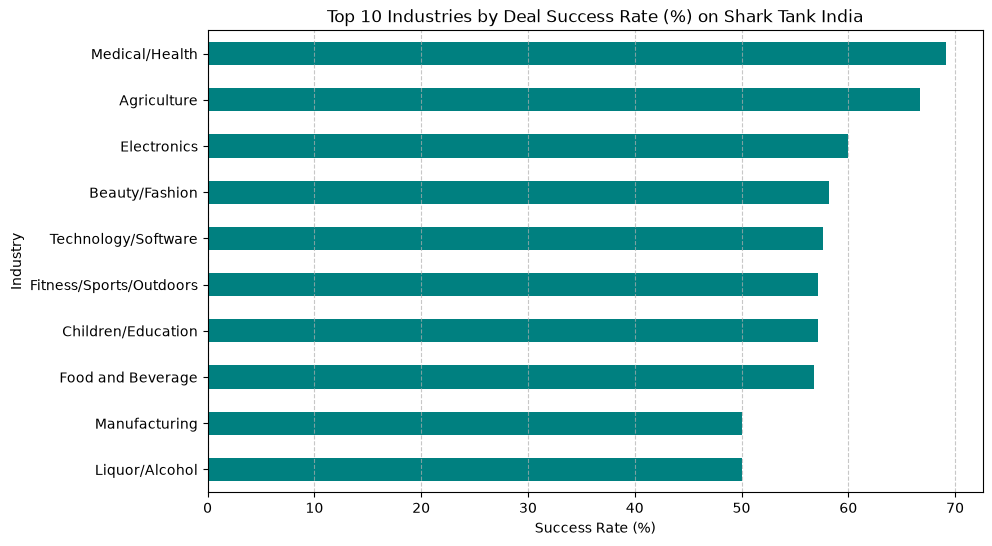

In [41]:
# Understanding better with bar graph
import matplotlib.pyplot as plt

# Plot Deal Success Rate by Industry
success_rates = shark_tank.groupby('Industry').apply(
    lambda x: (x['Total Deal Amount'] > 0).mean() * 100
).round(2).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
success_rates.plot(kind='barh', color='teal')
plt.title('Top 10 Industries by Deal Success Rate (%) on Shark Tank India')
plt.xlabel('Success Rate (%)')
plt.ylabel('Industry')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [37]:
# Saving Cleaned up data
shark_tank.to_csv('shark_tank_india_cleaned.csv', index=False)